# Task 3: Heart Disease Prediction
## Objective:
### Build a model to predict whether a person is at risk of heart disease based on their health data.


In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [113]:
df = pd.read_csv('Heart Disease UCI Dataset.csv')

In [114]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
230,37,M,ASY,130,315,0,Normal,158,N,0.0,Up,0
795,42,M,NAP,120,240,1,Normal,194,N,0.8,Down,0
593,64,M,ASY,130,258,1,LVH,130,N,0.0,Flat,1
650,48,M,ASY,130,256,1,LVH,150,Y,0.0,Up,1
615,70,M,ASY,130,322,0,LVH,109,N,2.4,Flat,1


## check dataset has any null value


In [41]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## perform EDA to understand trends

In [42]:
df.shape

(918, 12)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [44]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [45]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## check duplicates

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

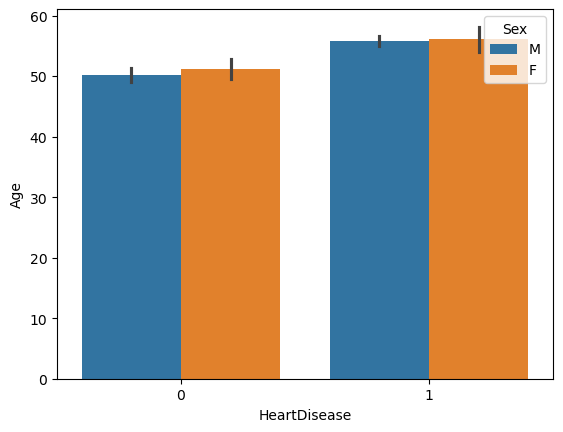

In [94]:
sns.barplot(x='HeartDisease', y='Age',hue='Sex',data=df)
plt.show()

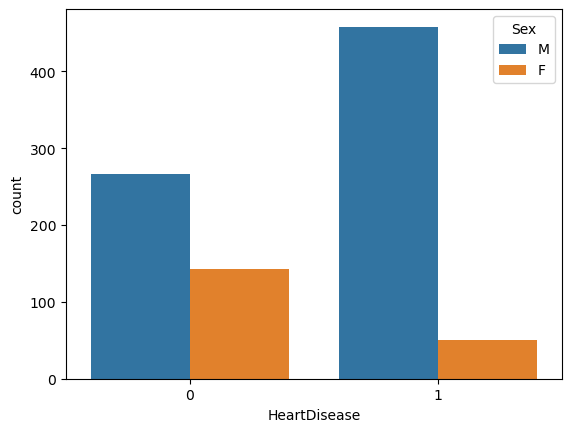

In [95]:
sns.countplot(x='HeartDisease', hue='Sex', data=df)
plt.show()

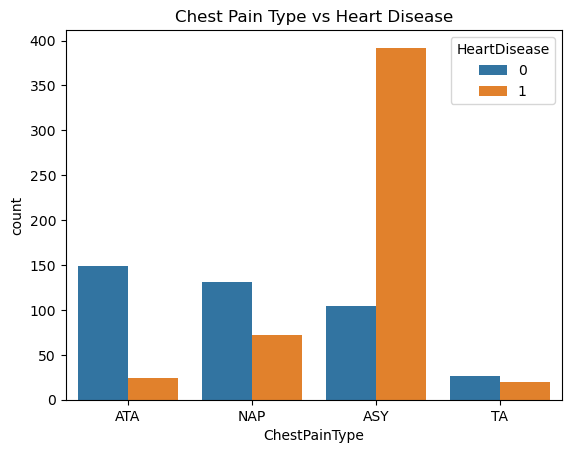

In [97]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

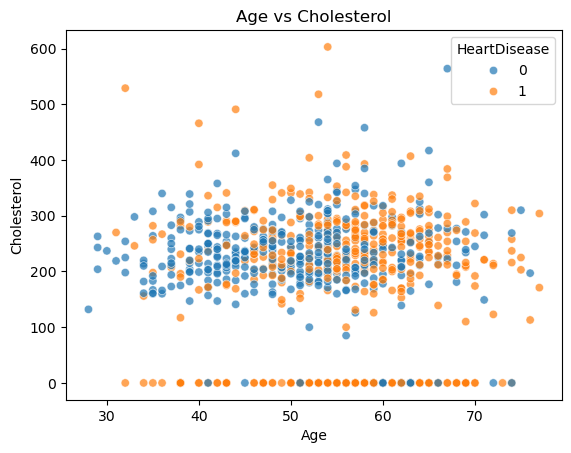

In [98]:
sns.scatterplot(x='Age', y='Cholesterol', hue='HeartDisease', data=df, alpha=0.7)
plt.title('Age vs Cholesterol')
plt.show()

In [101]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

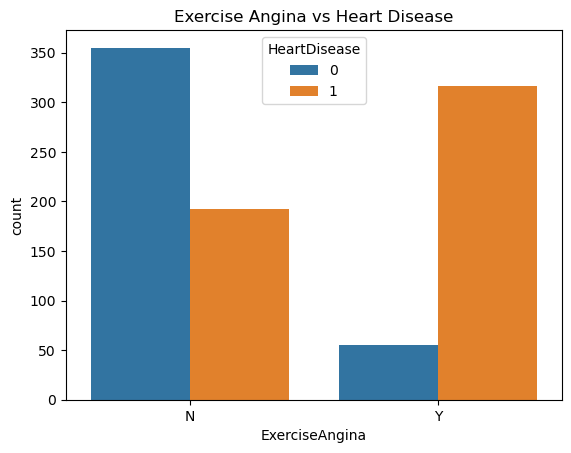

In [99]:
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=df)
plt.title('Exercise Angina vs Heart Disease')
plt.show()

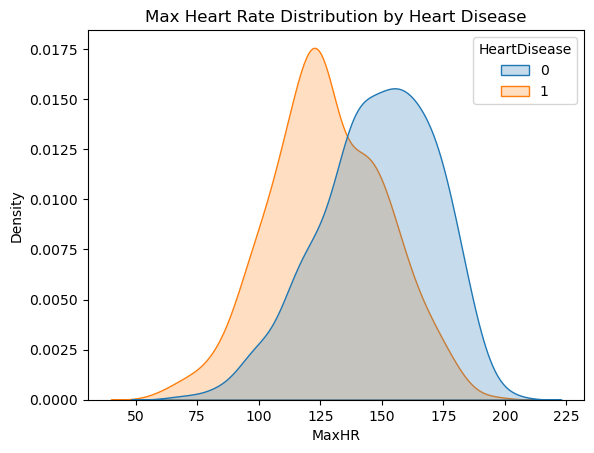

In [102]:
sns.kdeplot(data=df, x='MaxHR', hue='HeartDisease', fill=True, common_norm=False)
plt.title('Max Heart Rate Distribution by Heart Disease')
plt.show()


In [48]:
cat_colu = df.select_dtypes(include = 'object').columns

In [49]:
cat_colu

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

# Train a classification model and preprocessing

## split the dataset

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['HeartDisease']),df['HeartDisease'],test_size=0.2,random_state=42)

In [52]:
x_train.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
795,42,M,NAP,120,240,1,Normal,194,N,0.8,Down
25,36,M,NAP,130,209,0,Normal,178,N,0.0,Up


In [53]:
y_train.head(2)

795    0
25     0
Name: HeartDisease, dtype: int64

In [54]:
x_test.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
668,63,F,ATA,140,195,0,Normal,179,N,0.0,Up
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat


## converting categorical data into numerical

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [56]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(sparse_output=False),['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])
],remainder = 'passthrough')

In [62]:
x_train_transformed = transformer.fit_transform(x_train)

In [63]:
x_train_transformed

array([[  0. ,   1. ,   0. , ...,   1. , 194. ,   0.8],
       [  0. ,   1. ,   0. , ...,   0. , 178. ,   0. ],
       [  0. ,   1. ,   1. , ...,   1. , 125. ,   1. ],
       ...,
       [  0. ,   1. ,   1. , ...,   0. , 144. ,   1.4],
       [  0. ,   1. ,   1. , ...,   0. , 118. ,   0. ],
       [  1. ,   0. ,   1. , ...,   0. , 130. ,   2. ]], shape=(734, 20))

In [74]:
x_test_transformed = transformer.fit_transform(x_test)

In [59]:
## train model

In [67]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(x_train_transformed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
y_pred = model.predict(x_test_transformed)

In [76]:
y_pred

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [78]:
## accuracy

In [77]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8043478260869565


In [79]:
## confusion matrix

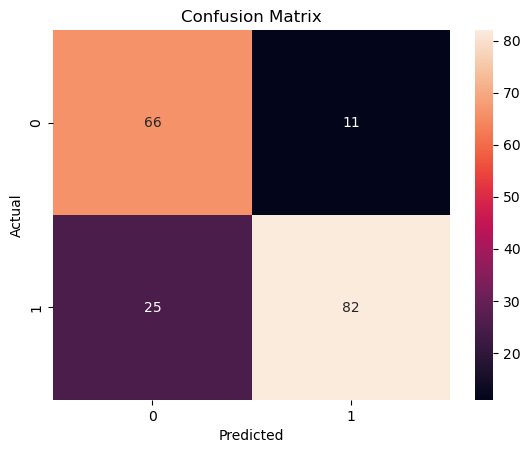

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

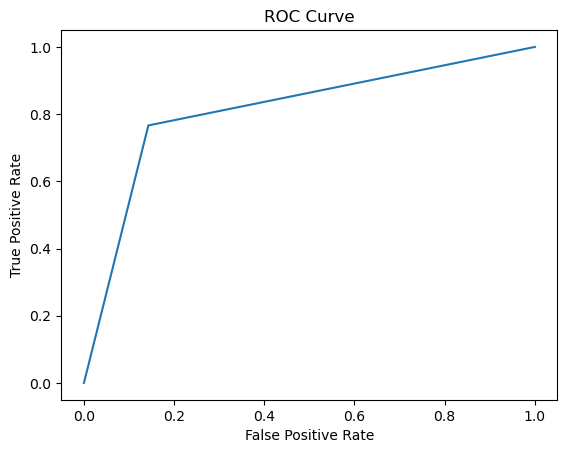

AUC Score: 0.8117489986648865


In [82]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(x_test_transformed)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

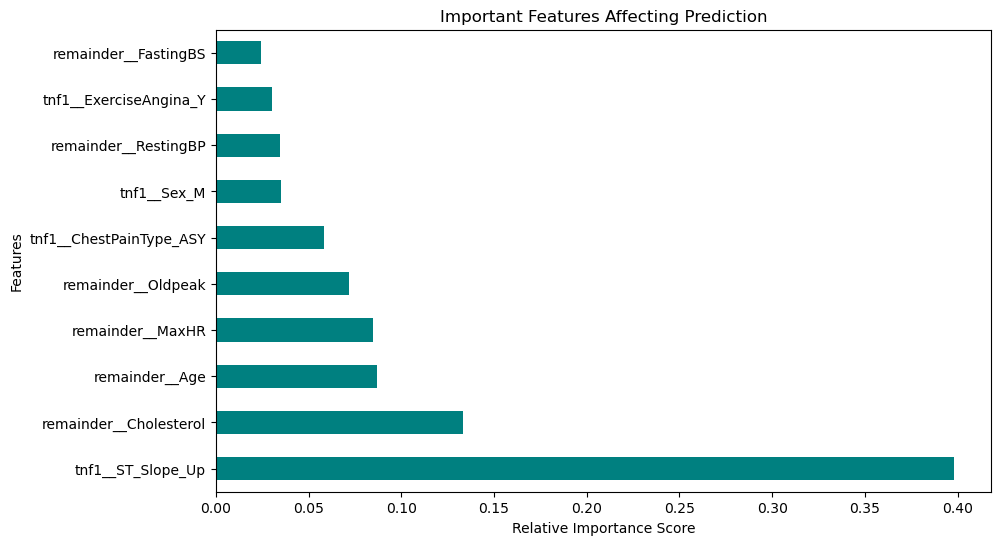

In [111]:
feature_names = transformer.get_feature_names_out()


importances = model.feature_importances_
feat_importances = pd.Series(importances, index=feature_names)


plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Important Features Affecting Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.show()
